In [71]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import os

#Load Data

In [2]:
#loading the data
df = pd.read_csv('Life Expectancy Data.csv')

In [3]:
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.shape

(2938, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [7]:
#summary stats
df.describe(include='all')

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938,2938.000000,2938,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,...,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
unique,193,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2007.518720,NaN,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,...,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,NaN,4.613841,NaN,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,...,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,NaN,2000.000000,NaN,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,...,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,NaN,2004.000000,NaN,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,...,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,NaN,2008.000000,NaN,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,...,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,NaN,2012.000000,NaN,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,...,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000


In [8]:
#identifying missing value
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [9]:
#identifying garberge values 
for i in df.select_dtypes(include="object").columns:
           print(df[i].value_counts())
           print("***"*10)

Country
Afghanistan              16
Peru                     16
Nicaragua                16
Niger                    16
Nigeria                  16
                         ..
Niue                      1
San Marino                1
Nauru                     1
Saint Kitts and Nevis     1
Dominica                  1
Name: count, Length: 193, dtype: int64
******************************
Status
Developing    2426
Developed      512
Name: count, dtype: int64
******************************


In [10]:
#checking duplicates
df.duplicated().sum()

0

In [11]:
# identifying date types
df.dtypes


Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

#Exploratory data analysis(EDA)


In [12]:
# descriptive statistics
df.describe()


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [13]:
df.describe(include='object')

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


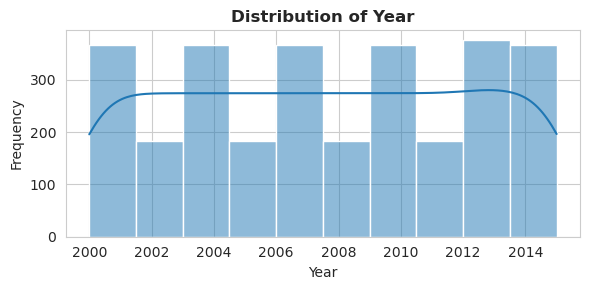

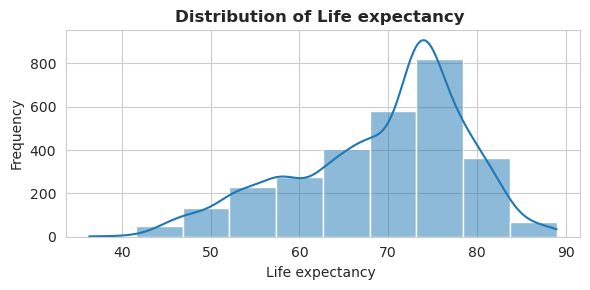

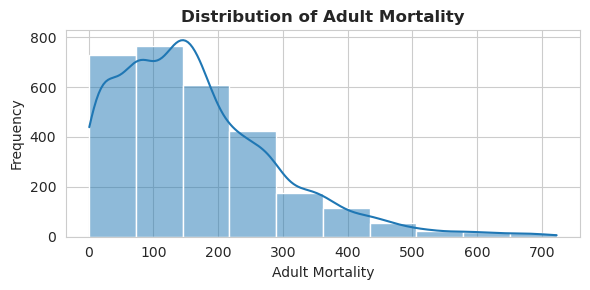

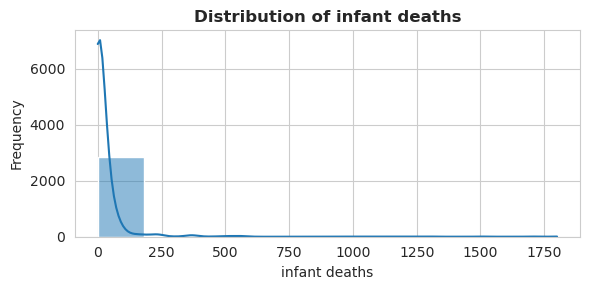

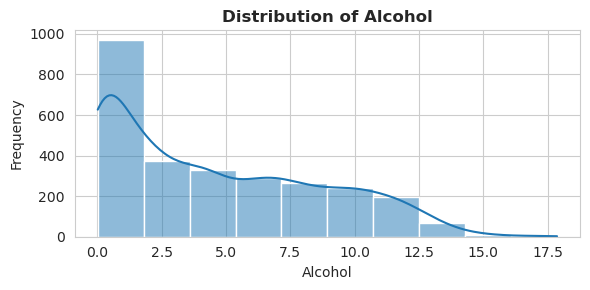

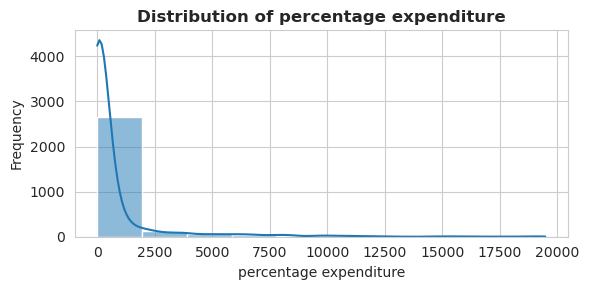

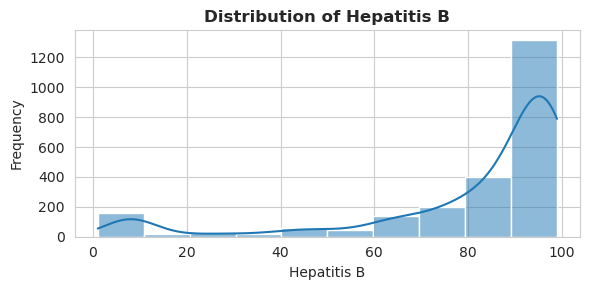

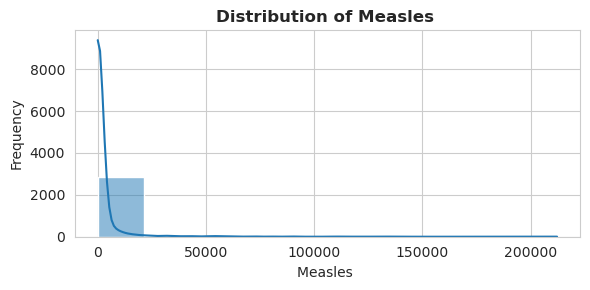

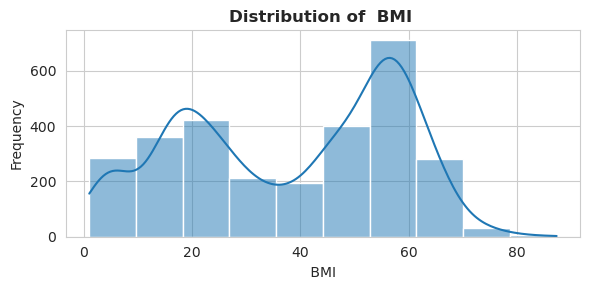

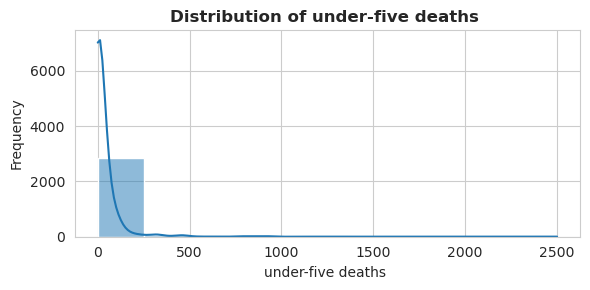

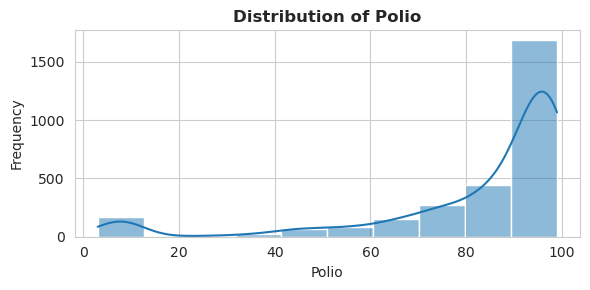

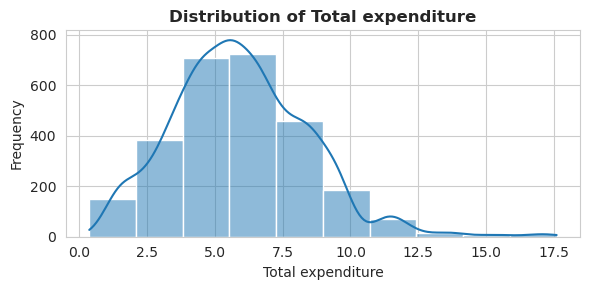

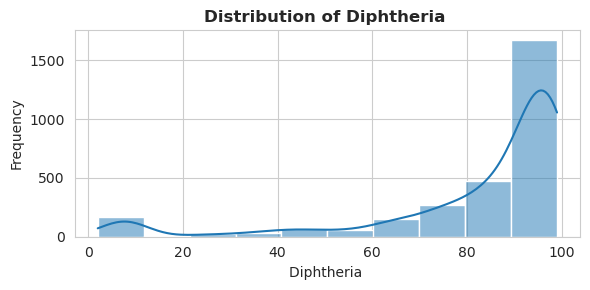

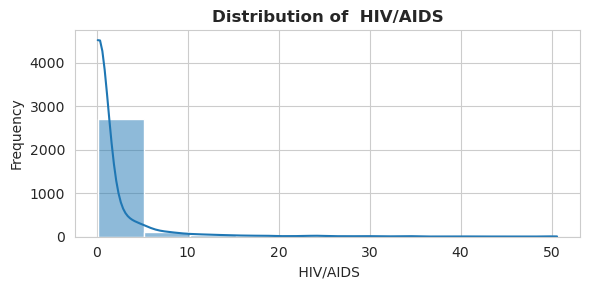

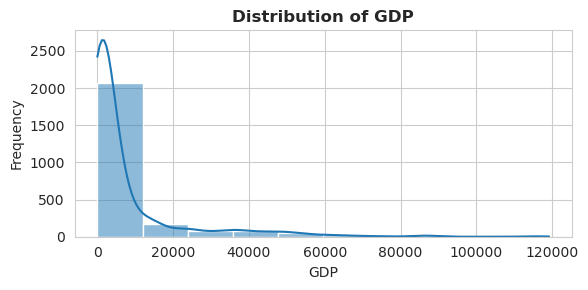

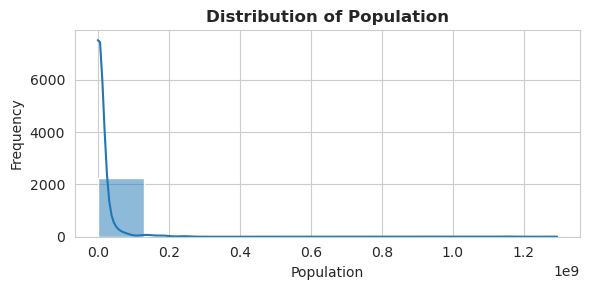

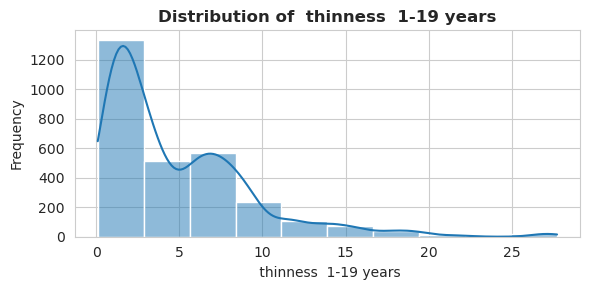

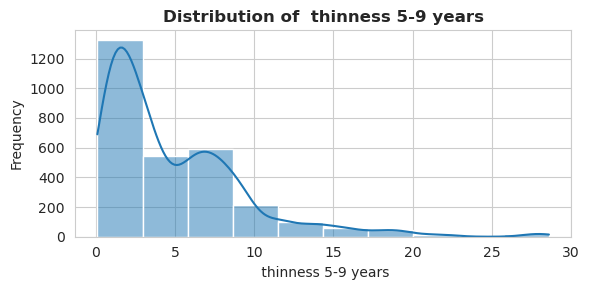

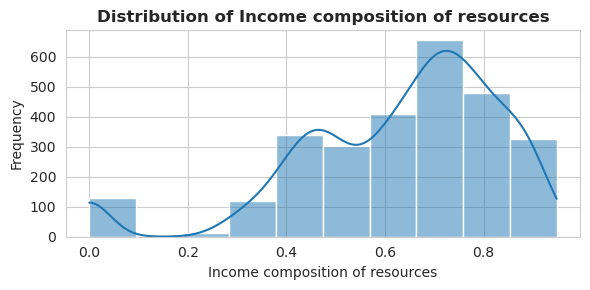

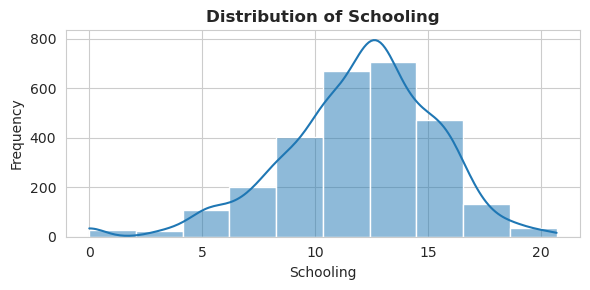

In [14]:
#histogram to understand the distribution for numeric data
sns.set_style("whitegrid")
for i in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    
    sns.histplot(data=df, x=i, bins=10, kde=True)
    
    plt.title(f"Distribution of {i}", fontsize=12, weight='bold')
    plt.xlabel(i)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

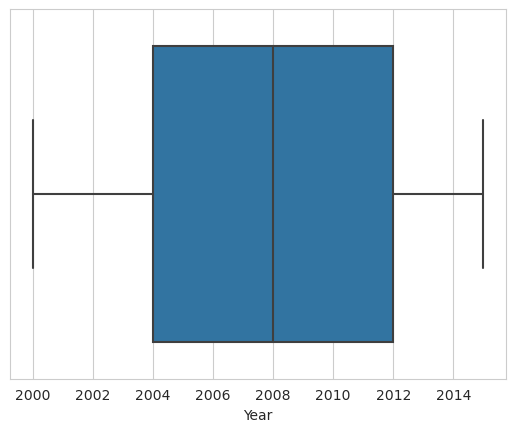

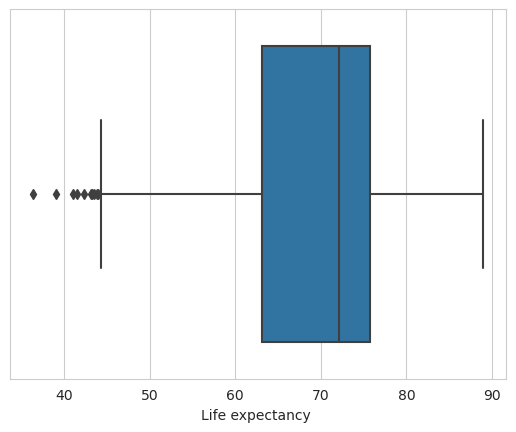

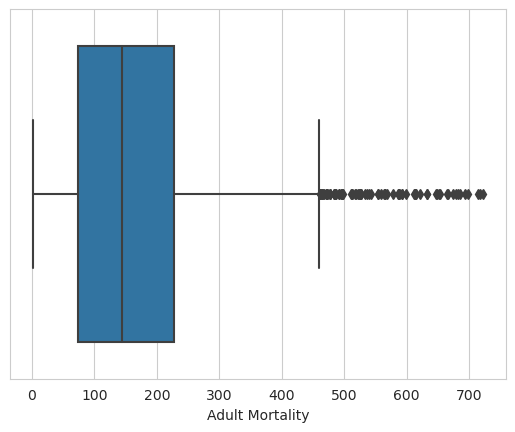

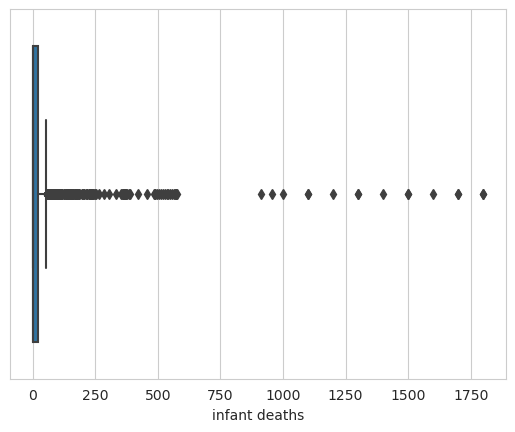

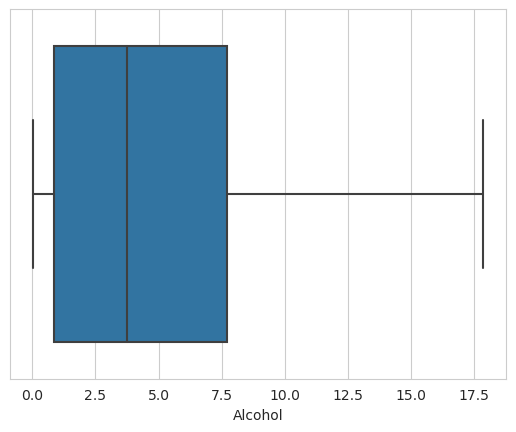

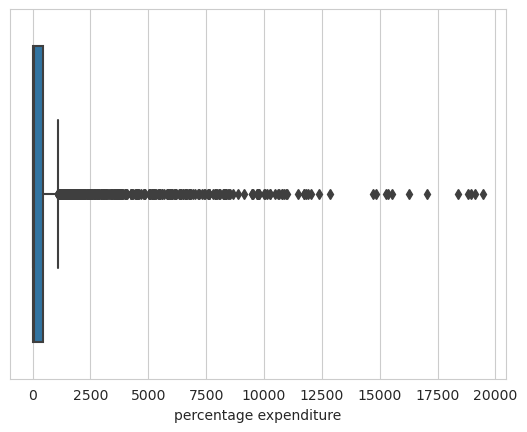

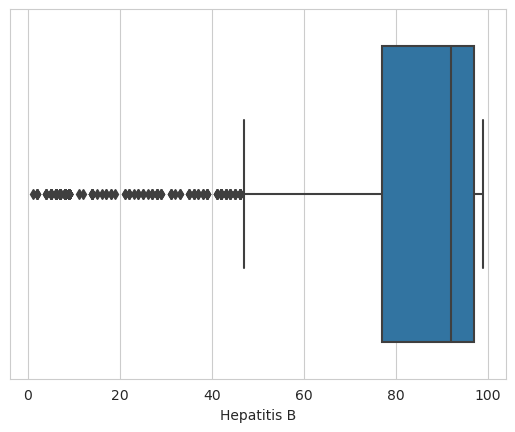

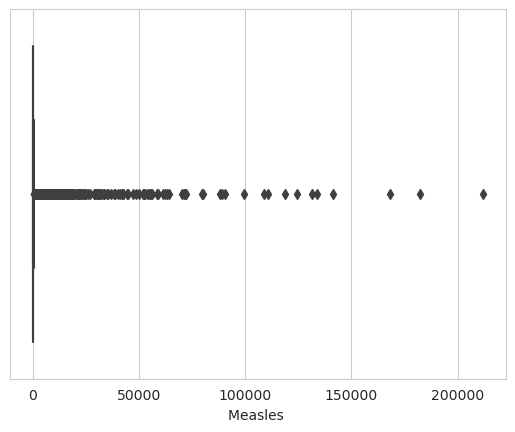

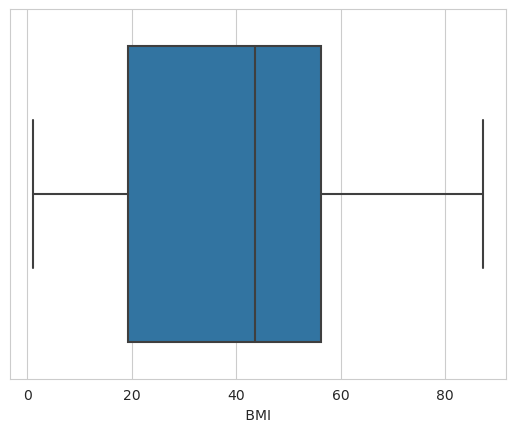

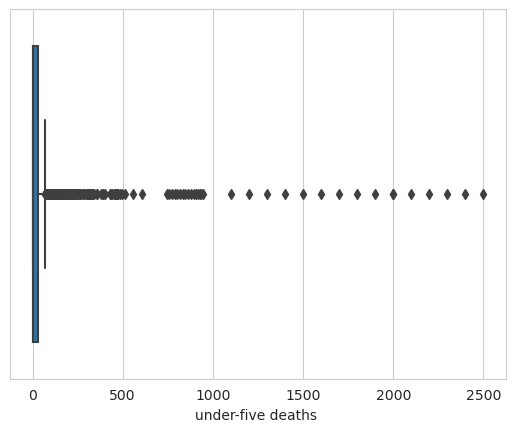

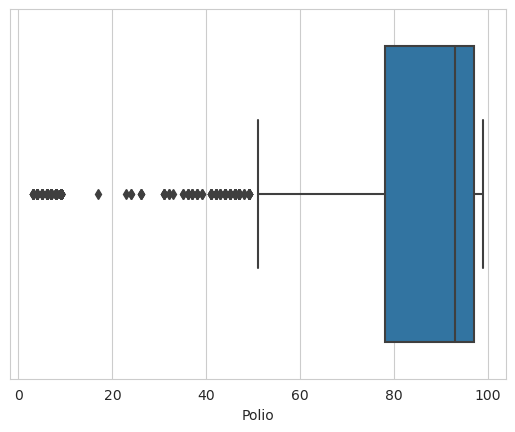

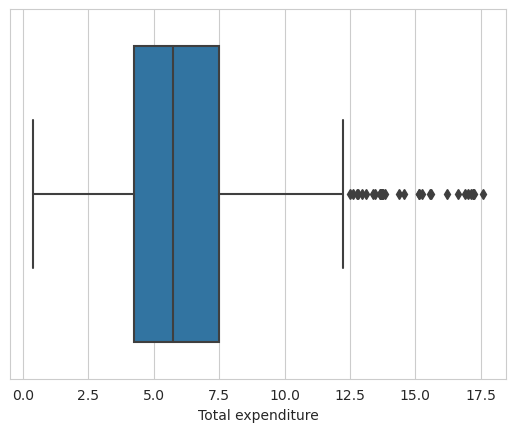

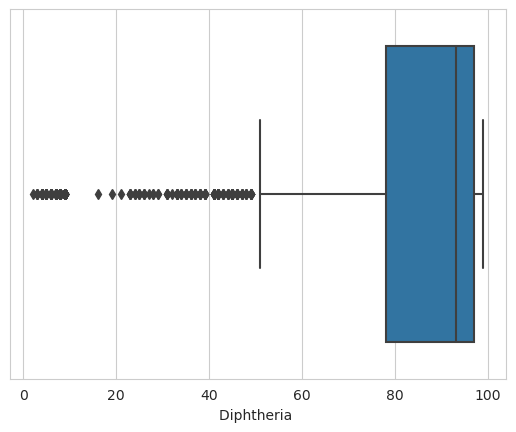

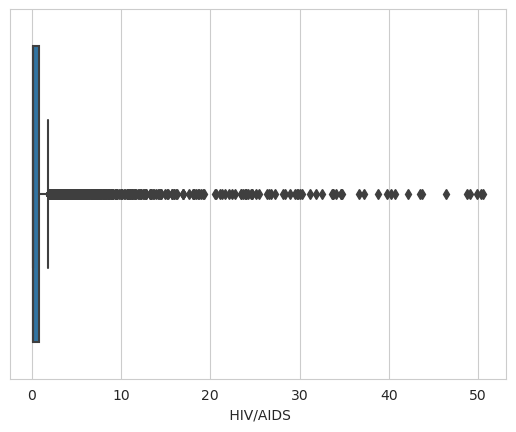

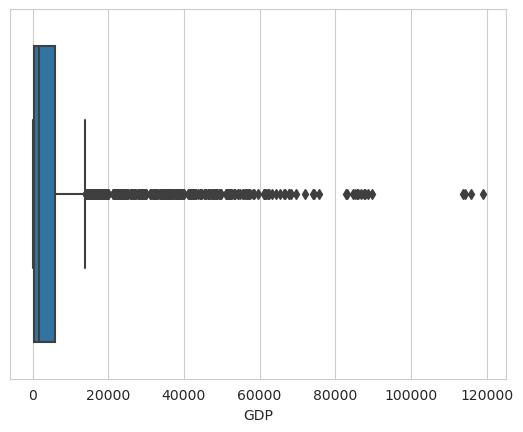

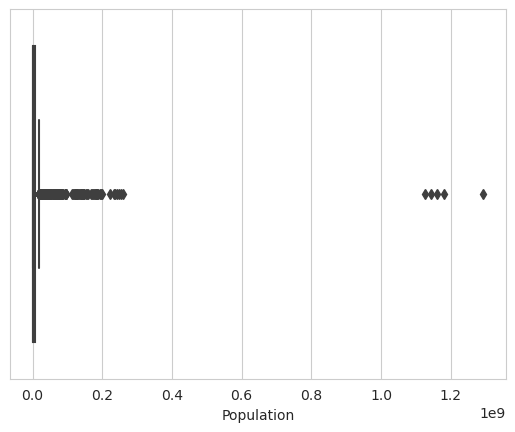

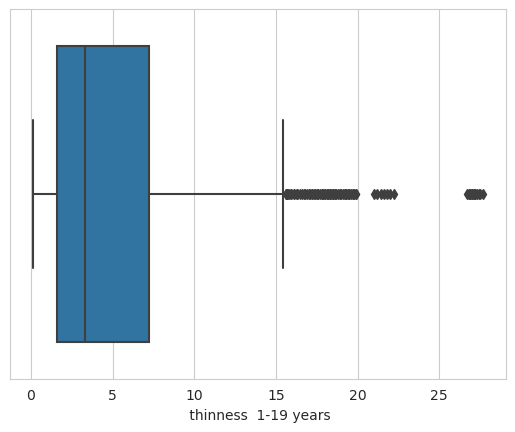

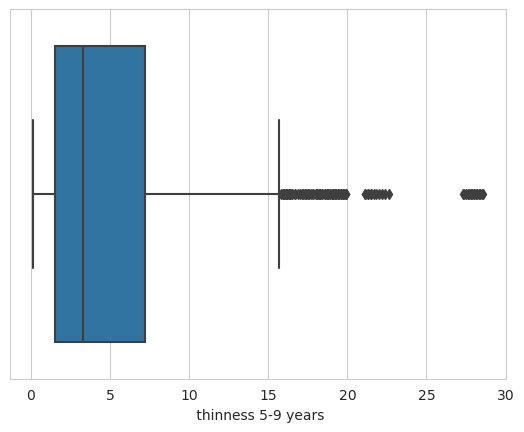

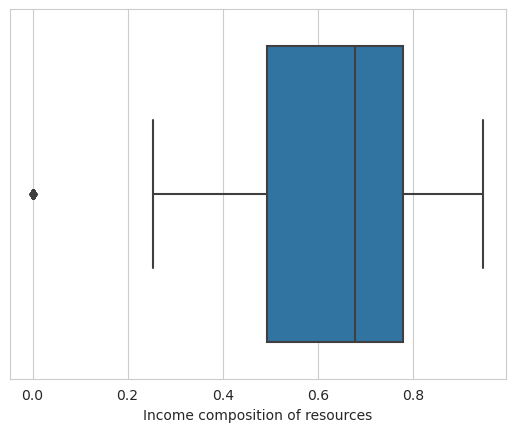

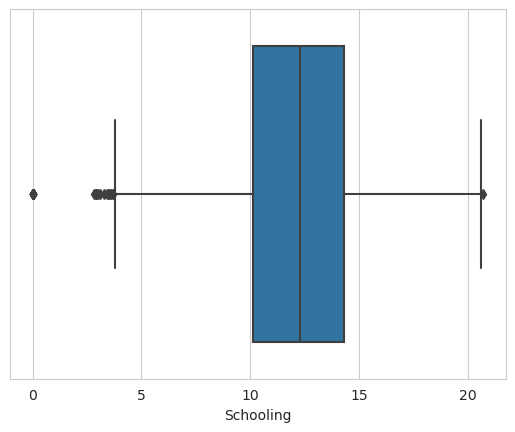

In [15]:
#boxplot to identify outliers
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

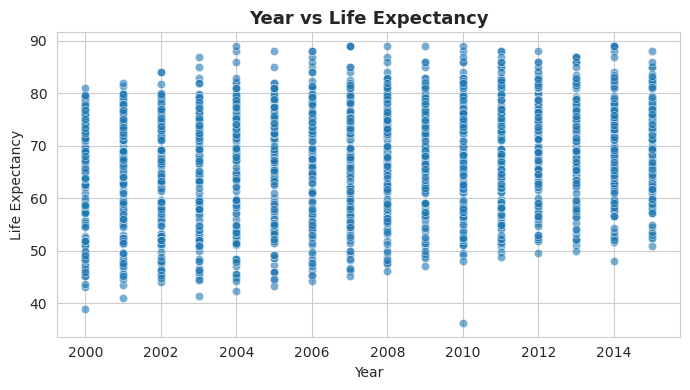

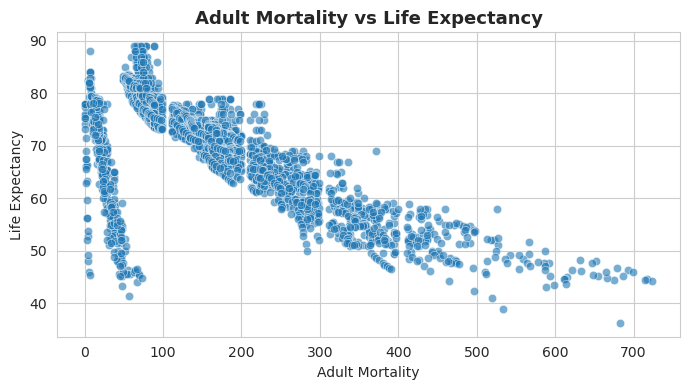

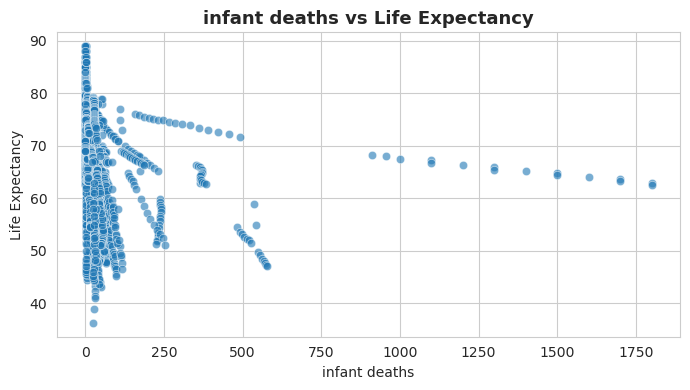

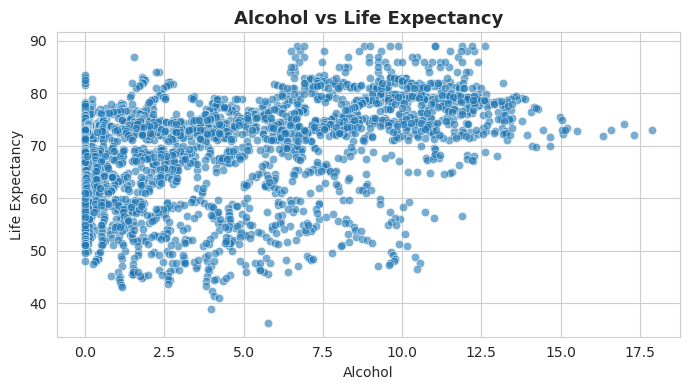

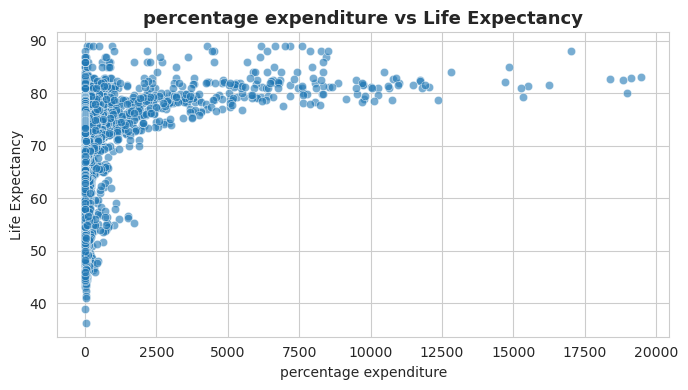

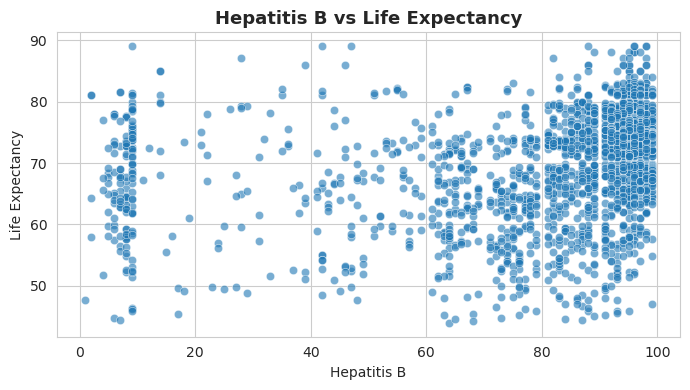

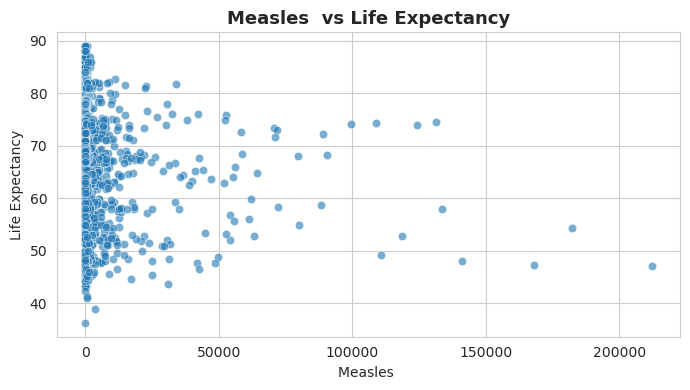

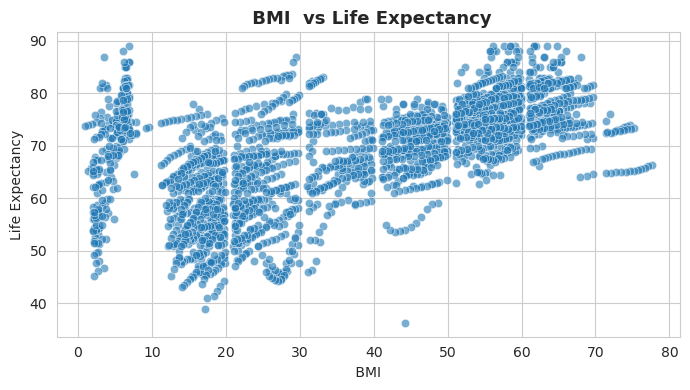

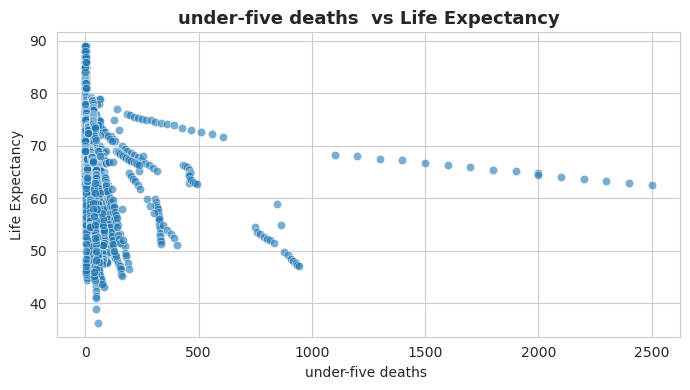

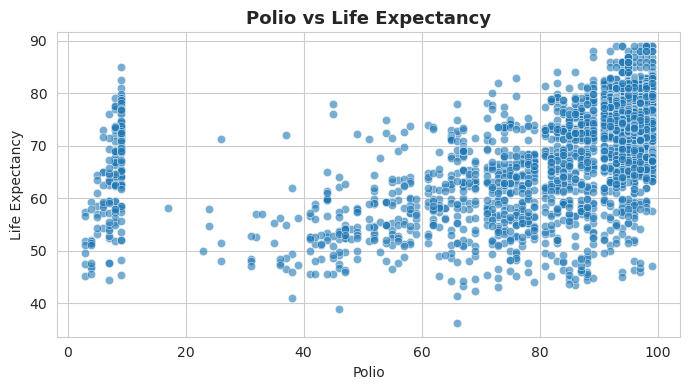

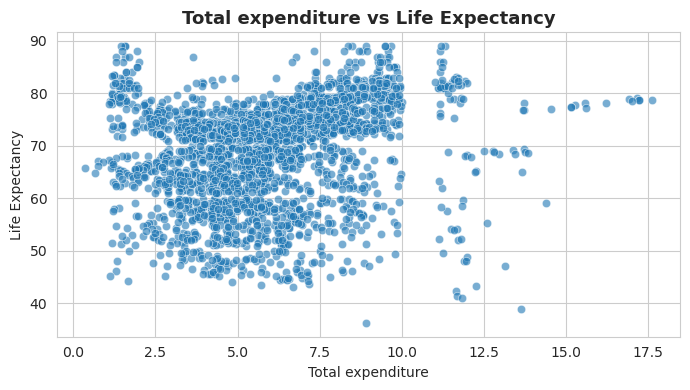

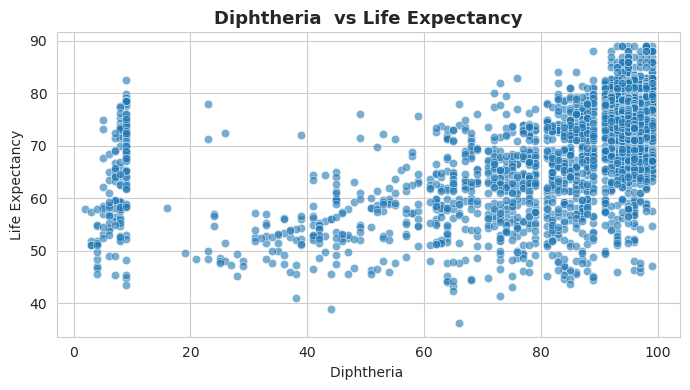

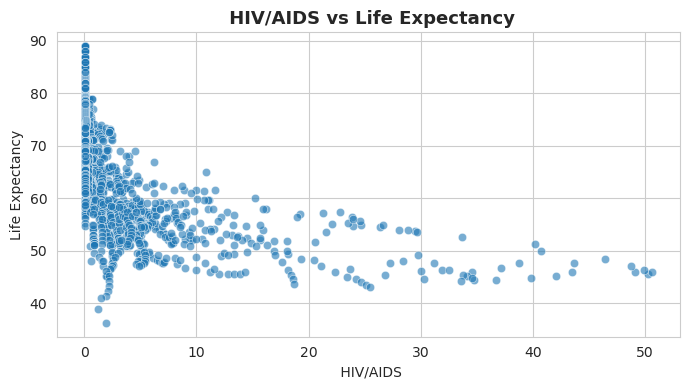

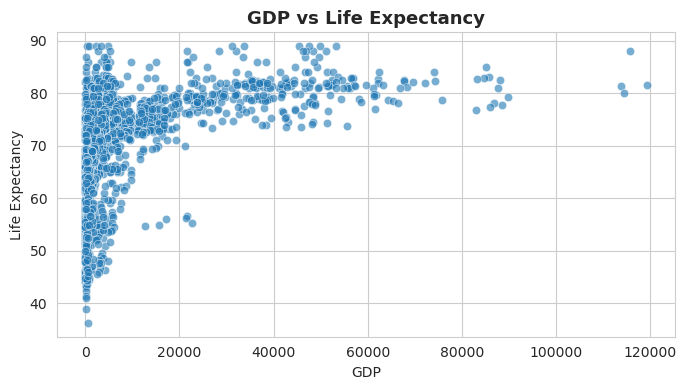

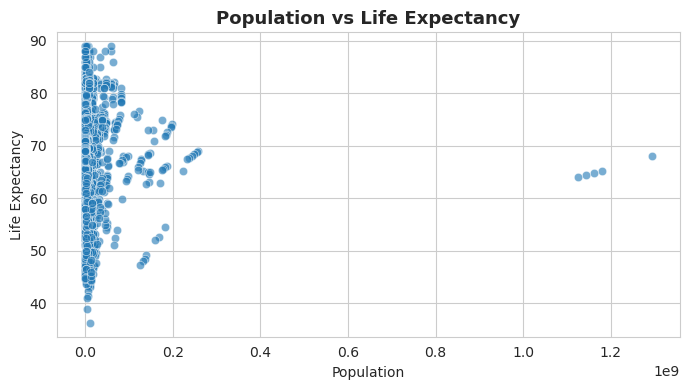

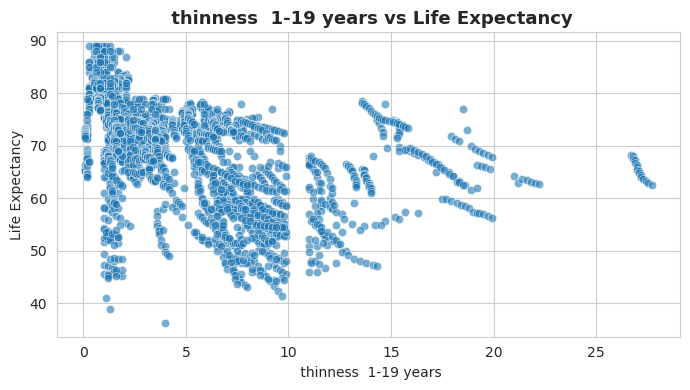

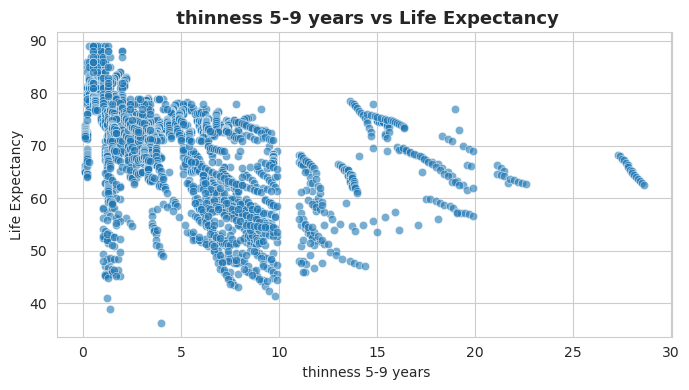

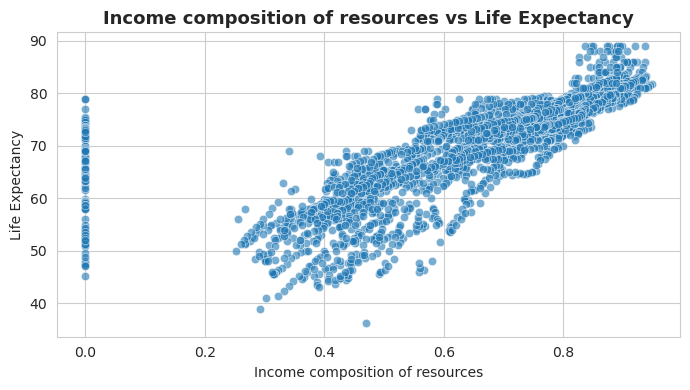

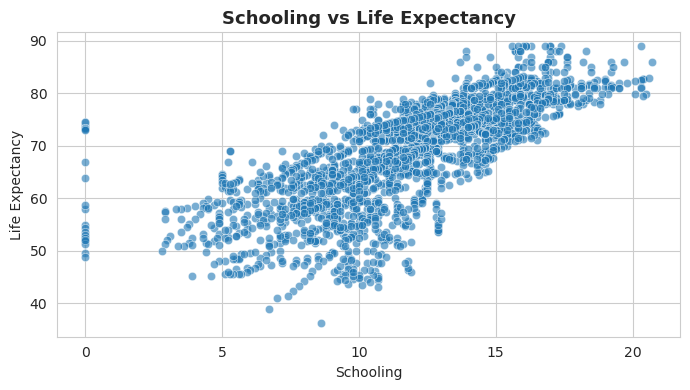

In [16]:
#scatter plot for relationship
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

for i in ['Year','Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling']:

    plt.figure(figsize=(7,4))
    
    sns.scatterplot(
        data=df,
        x=i,
        y='Life expectancy ',
        alpha=0.6   # helps overlapping points
    )
    
    plt.title(f"{i} vs Life Expectancy", fontsize=13, weight='bold')
    plt.xlabel(i)
    plt.ylabel("Life Expectancy")
    plt.tight_layout()
    plt.show()

In [17]:
df.select_dtypes(include="number").columns


Index(['Year', 'Life expectancy ', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [18]:
#correlation with heatmap to innterpret the relation and multiclliarity
d=df.select_dtypes(include="number").corr()

<Axes: >

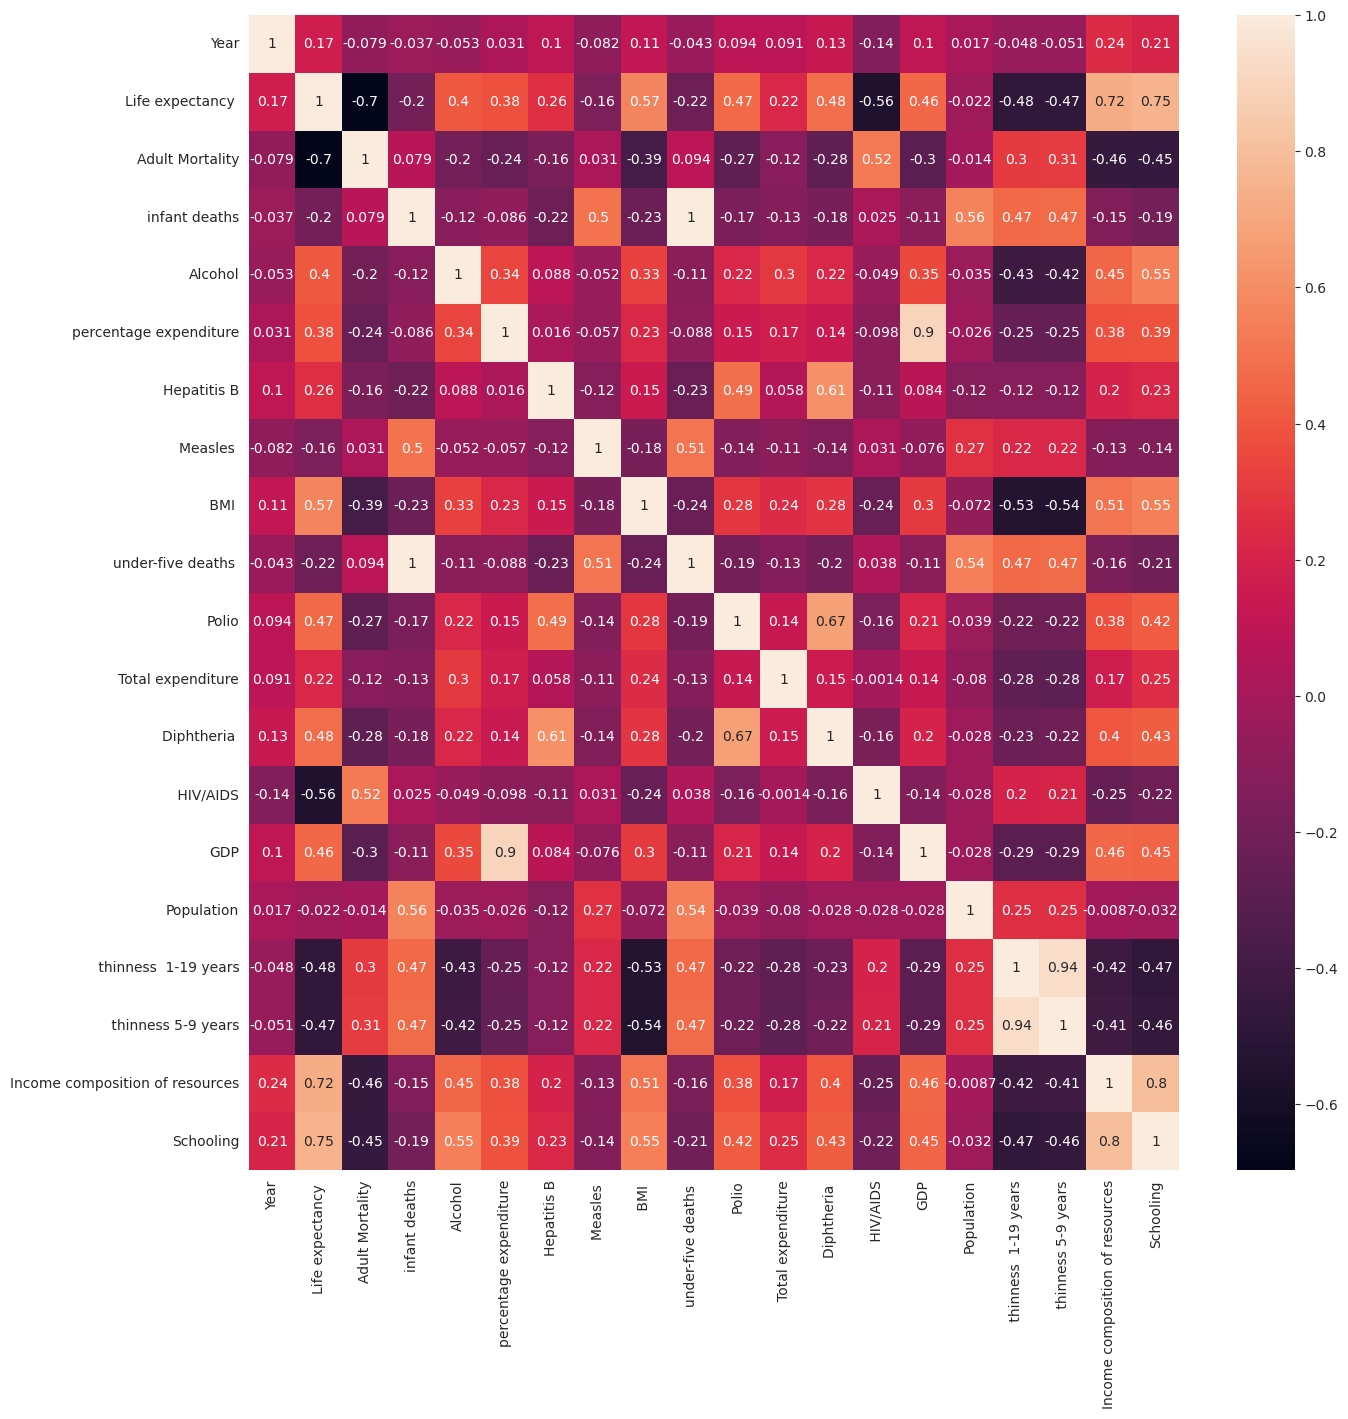

In [19]:
plt.figure(figsize=(15,15))
sns.heatmap(d,annot=True)

#missing value treat ment

In [20]:
#handling missing values or impute 
for i in [" BMI ","Polio","Income composition of resources"]:
    df[i].fillna(df[i].median(),inplace = True)

In [21]:
from sklearn.impute import KNNImputer
impute = KNNImputer()

In [22]:
for i in df.select_dtypes(include="number").columns:
    values = df[[i]].values  # Extract as numpy array
    df[i] = impute.fit_transform(values).ravel()
    

In [23]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

#outlier treatment

In [24]:
def wisker(col):
    q1,q3=np.percentile(col,[24,75])
    iqr=q3-q1
    lw=q1-1.5*iqr
    uw=q3+1.5*iqr
    return lw,uw

In [25]:
wisker(df['GDP'])

(-9855.256300157711, 17886.207330716185)

In [26]:
for i in ['GDP', 'Total expenditure', ' thinness 5-9 years', ' thinness  1-19 years']:
    lw,uw=wisker(df[i])
    df[i]=np.where(df[i]<lw,lw,df[i])
    df[i]=np.where(df[i]>uw,uw,df[i])

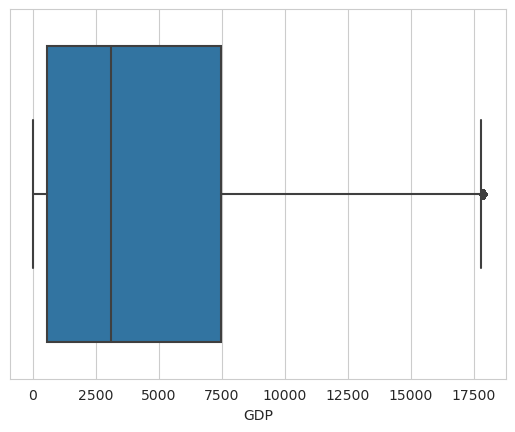

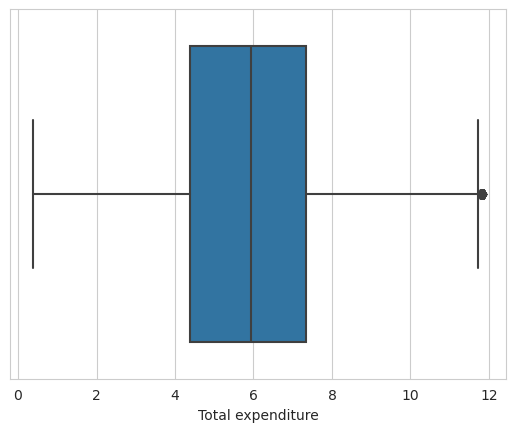

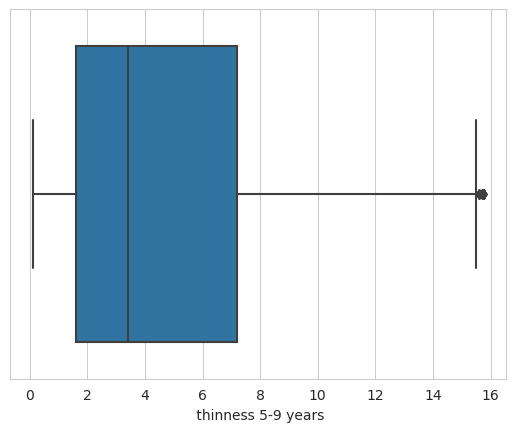

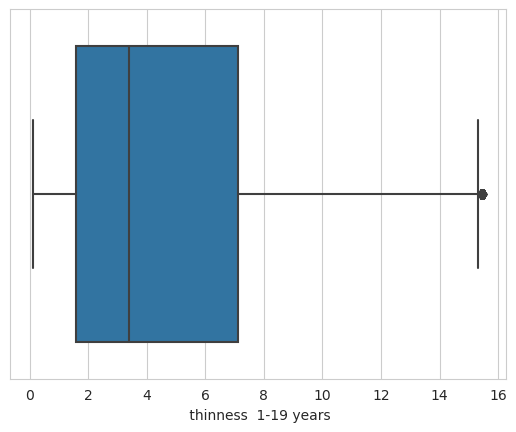

In [28]:
for i in ['GDP', 'Total expenditure', ' thinness 5-9 years', ' thinness  1-19 years']:
    sns.boxplot(data=df, x=i)
    plt.show()

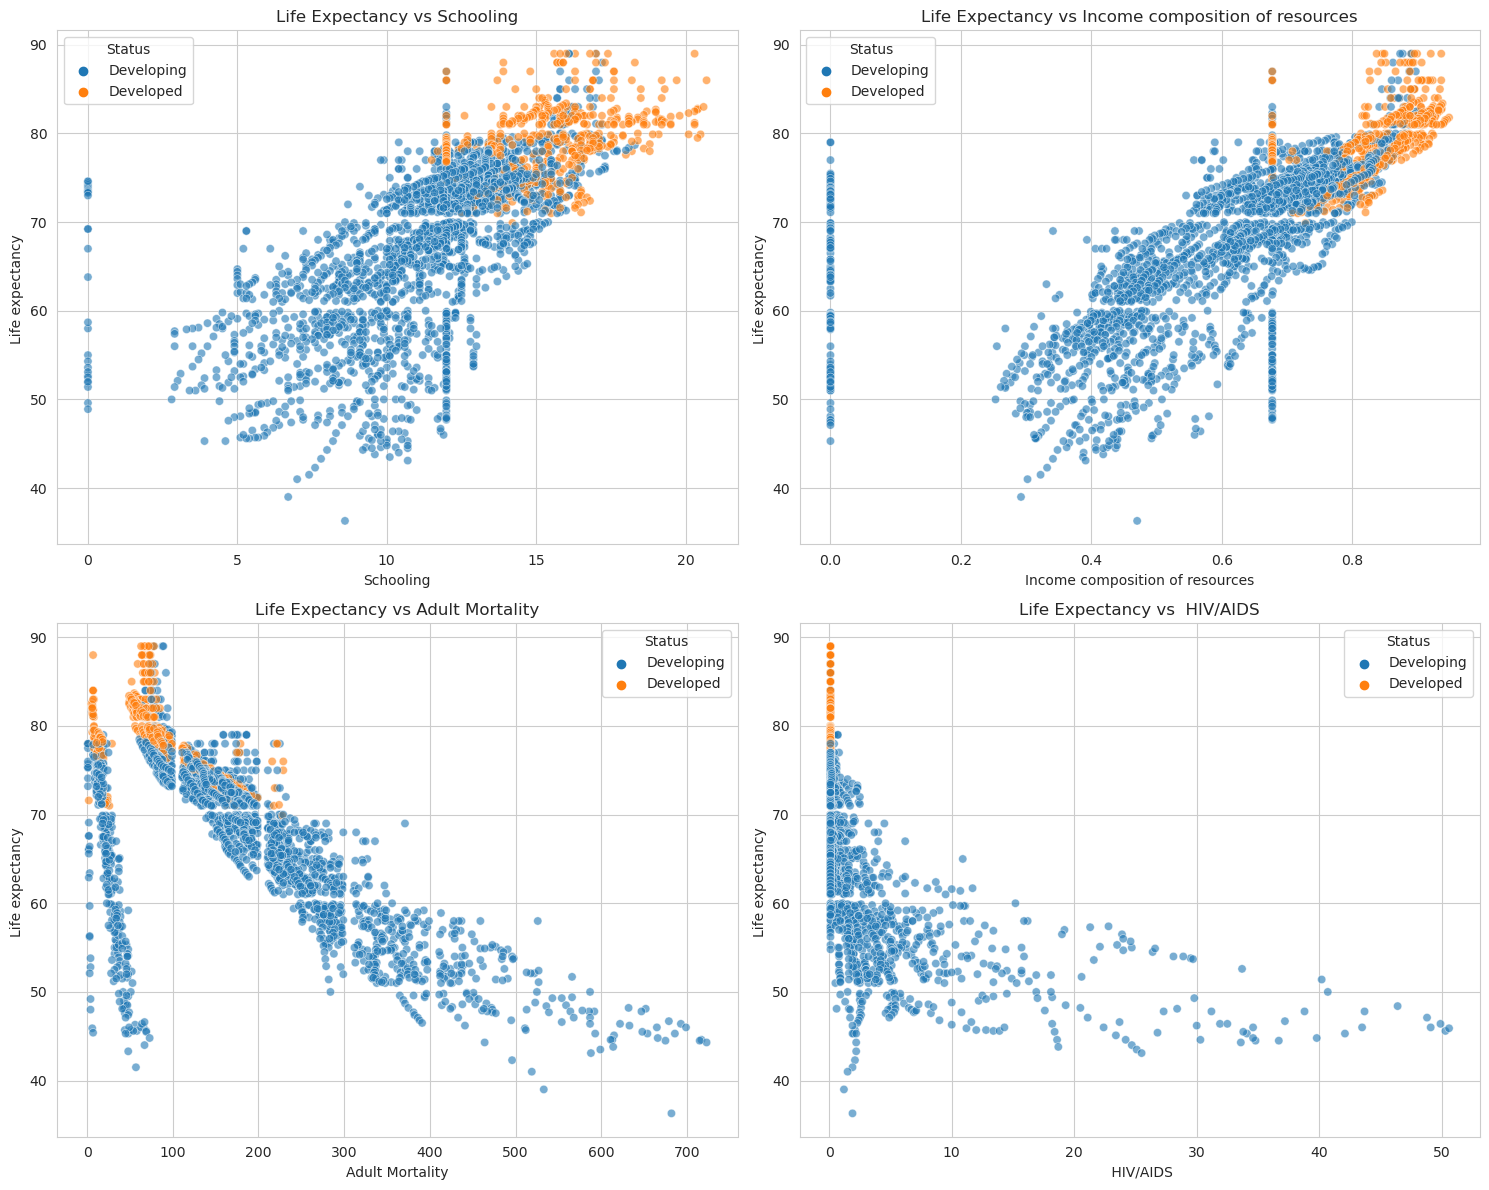

In [49]:
#  Scatter plots for high correlation with Life Expectancy
high_corr_features = ['Schooling', 'Income composition of resources', 'Adult Mortality', ' HIV/AIDS']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(high_corr_features):
    sns.scatterplot(data=df, x=col, y='Life expectancy ', hue='Status', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Life Expectancy vs {col}')

plt.tight_layout()
plt.show()



#Status

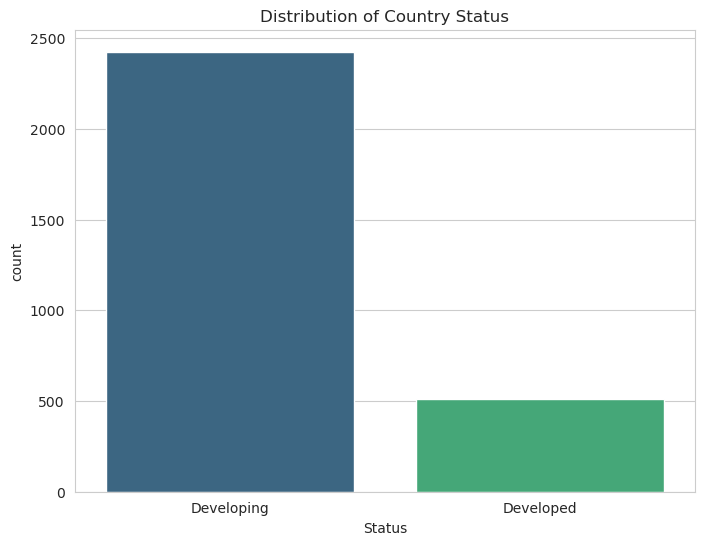

In [37]:
# 1. Categorical Analysis: Status
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Status', palette='viridis')
plt.title('Distribution of Country Status')
plt.show()


#Bivariate Analysis: Categorical vs Numerical

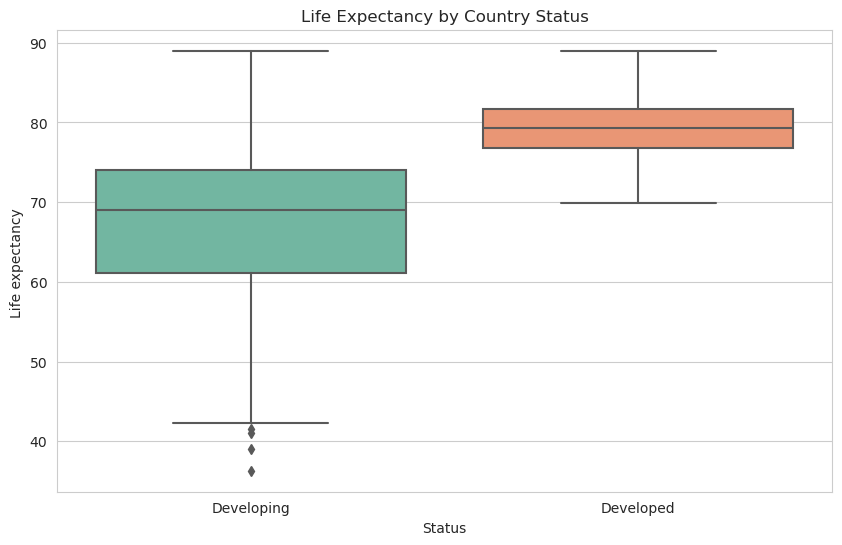

In [40]:
# 1. Status vs Life Expectancy (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Life expectancy ', palette='Set2')
plt.title('Life Expectancy by Country Status')
plt.show()


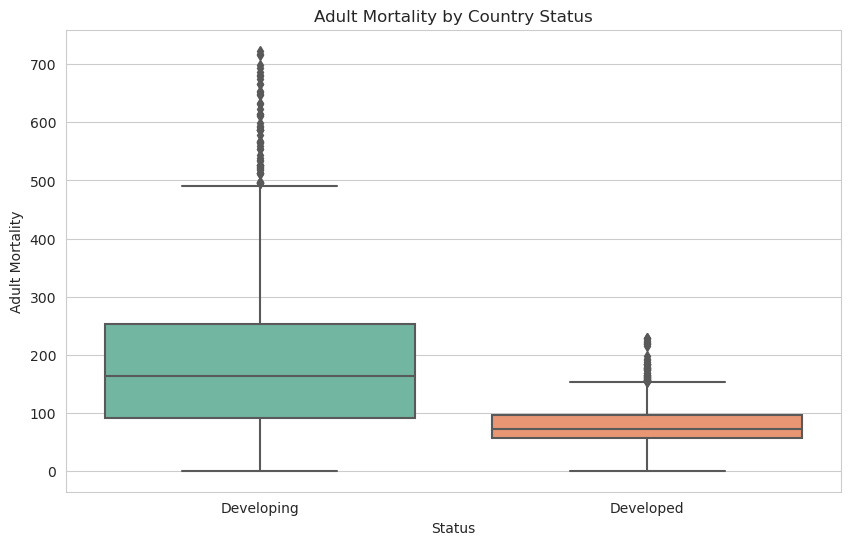

In [41]:
# 2. Status vs Adult Mortality
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Adult Mortality', palette='Set2')
plt.title('Adult Mortality by Country Status')
plt.show()

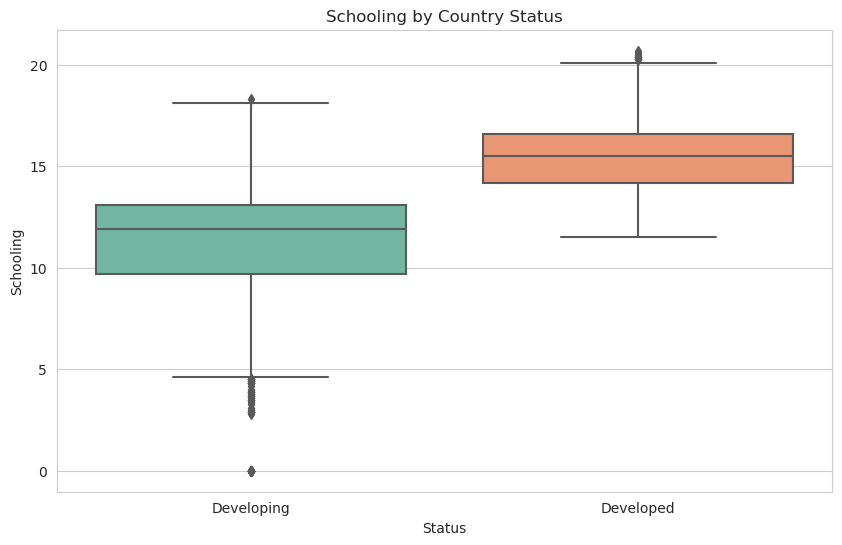

In [42]:
# 3. Status vs Schooling
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Schooling', palette='Set2')
plt.title('Schooling by Country Status')
plt.show()

In [44]:
# Statistical summary by Status
summary_by_status = df.groupby('Status')[['Life expectancy ', 'Adult Mortality', 'Schooling', 'GDP']].mean()
print("\n--- Mean Values by Status ---")
print(summary_by_status)


--- Mean Values by Status ---
            Life expectancy   Adult Mortality  Schooling           GDP
Status                                                                
Developed          79.197852        79.685547  15.484285  10557.105469
Developing         67.120177       182.758848  11.255924   4007.432856


In [55]:
# Print top correlations with Life Expectancy which has the most relashionship
print("\n--- Top Correlations with Life Expectancy ---")
print(df['Life expectancy '].sort_values(ascending=False))




--- Top Correlations with Life Expectancy ---
1850    89.0
915     89.0
241     89.0
2433    89.0
2513    89.0
        ... 
2308    42.3
2309    41.5
2311    41.0
2312    39.0
1127    36.3
Name: Life expectancy , Length: 2938, dtype: float64




 #Feature Engineering 

In [56]:
#life class depending on life expectancy
df['Life_Class'] = pd.cut(
    df['Life expectancy '],
    bins=[0, 55, 70, 100],
    labels=['Low', 'Medium', 'High']
)

In [58]:

df['Immunization_avg'] = (
    df['Hepatitis B'] +
    df['Polio'] +
    df['Diphtheria ']
) / 3

In [59]:
#gdp sometimes can be too big log is good for predictions
df['log_GDP'] = np.log1p(df['GDP'])


In [66]:
#from numeric to categorial it helps with classification model
df['Alcohol_Level'] = pd.cut(
    df['Alcohol'],
    bins=[0, 3, 8, 20],
    labels=['Low', 'Moderate', 'High']
)

In [67]:
df.dtypes

Country                              object
Year                                float64
Status                               object
Life expectancy                     float64
Adult Mortality                     float64
infant deaths                       float64
Alcohol                             float64
percentage expenditure              float64
Hepatitis B                         float64
Measles                             float64
 BMI                                float64
under-five deaths                   float64
Polio                               float64
Total expenditure                   float64
Diphtheria                          float64
 HIV/AIDS                           float64
GDP                                 float64
Population                          float64
 thinness  1-19 years               float64
 thinness 5-9 years                 float64
Income composition of resources     float64
Schooling                           float64
Life_Class                      


##Categorial Encoding 

In [72]:
#Target encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Life_Class'] = le.fit_transform(df['Life_Class'])
#Low → 0 Medium → 1 High → 2

In [73]:
#binary encoding(0/1) binary classification
df['Status'] = df['Status'].map({
    'Developing': 0,
    'Developed': 1
})

In [74]:
#One-Hot Encoding 
#on dropping on first one To avoid multicollinearity (important for linear/logistic regression). 
df = pd.get_dummies(df, columns=['Alcohol_Level'], drop_first=True)
# only moderate and high 


In [75]:
df = df.drop('Country', axis=1)
#Too many dummy variables
#Overfitting risk

In [78]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
2933
2934
2935
2936


In [79]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life_Class,Immunization_avg,log_GDP,Alcohol_Level_Moderate,Alcohol_Level_High
0,2015.0,0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,...,33736494.0,15.5,15.75,0.479,10.1,2,45.333333,6.372055,False,False
1,2014.0,0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,...,327582.0,15.5,15.75,0.476,10.0,2,60.666667,6.419501,False,False
2,2013.0,0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,...,31731688.0,15.5,15.75,0.470,9.9,2,63.333333,6.450067,False,False
3,2012.0,0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,...,3696958.0,15.5,15.75,0.463,9.8,2,67.000000,6.508708,False,False
4,2011.0,0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,...,2978599.0,15.5,15.75,0.454,9.5,2,68.000000,4.167242,False,False


In [80]:
df.tail()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life_Class,Immunization_avg,log_GDP,Alcohol_Level_Moderate,Alcohol_Level_High
2933,2004.0,0,44.3,723.0,27.0,4.36,0.0,68.0,31.0,27.1,...,12777511.0,9.4,9.4,0.407,9.2,1,66.666667,6.121103,True,False
2934,2003.0,0,44.5,715.0,26.0,4.06,0.0,7.0,998.0,26.7,...,12633897.0,9.8,9.9,0.418,9.5,1,27.333333,6.118870,True,False
2935,2002.0,0,44.8,73.0,25.0,4.43,0.0,73.0,304.0,26.3,...,125525.0,1.2,1.3,0.427,10.0,1,72.333333,4.066431,True,False
2936,2001.0,0,45.3,686.0,25.0,1.72,0.0,76.0,529.0,25.9,...,12366165.0,1.6,1.7,0.427,9.8,1,75.666667,6.309168,False,False
2937,2000.0,0,46.0,665.0,24.0,1.68,0.0,79.0,1483.0,25.5,...,12222251.0,11.0,11.2,0.434,9.8,1,78.333333,6.306930,False,False


##Feature Selection


Some variables are redundant

Some are weak predictors

Some create multicollinearity

Too many features = overfitting risk

 What this pipeline does:

Captures linear relationships via F-regression.

Captures nonlinear relationships via Random Forest.

Union of top features ensures nothing important is missed.

Removes highly correlated/redundant features to reduce overfitting and multicollinearity.

Output: final_features → ready for any regression or tree-based model.

In [81]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression


In [88]:
target = 'Life expectancy '

# Numeric features only (categorical already handled)
X = df.drop(columns=[target])
y = df[target]

In [89]:
# 1. F-Regression Selection
selector_f = SelectKBest(score_func=f_regression, k=12)
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=X.columns)
top_f_features = f_scores.sort_values(ascending=False).head(12).index.tolist()

In [91]:
from sklearn.ensemble import RandomForestRegressor
# 2. Random Forest Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_rf_features = rf_importances.sort_values(ascending=False).head(12).index.tolist()

In [92]:
# 3. Union of Top Features
candidate_features = list(set(top_f_features) | set(top_rf_features))
print(f"Candidate features (union of F-test & RF): {len(candidate_features)}")
print(candidate_features)


Candidate features (union of F-test & RF): 16
[' thinness 5-9 years', 'Adult Mortality', 'GDP', 'Income composition of resources', 'Year', 'log_GDP', 'Diphtheria ', 'under-five deaths ', ' HIV/AIDS', ' BMI ', 'Life_Class', 'Total expenditure', ' thinness  1-19 years', 'Alcohol', 'Status', 'Schooling']


In [94]:
# 4. Remove Highly Correlated Features
corr_matrix = df[candidate_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [95]:
# Drop features with correlation > 0.8
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
final_features = [f for f in candidate_features if f not in to_drop]

In [96]:
print(f"\nFinal selected features after removing redundancy: {len(final_features)}")
print(final_features)


Final selected features after removing redundancy: 14
[' thinness 5-9 years', 'Adult Mortality', 'GDP', 'Income composition of resources', 'Year', 'Diphtheria ', 'under-five deaths ', ' HIV/AIDS', ' BMI ', 'Life_Class', 'Total expenditure', 'Alcohol', 'Status', 'Schooling']


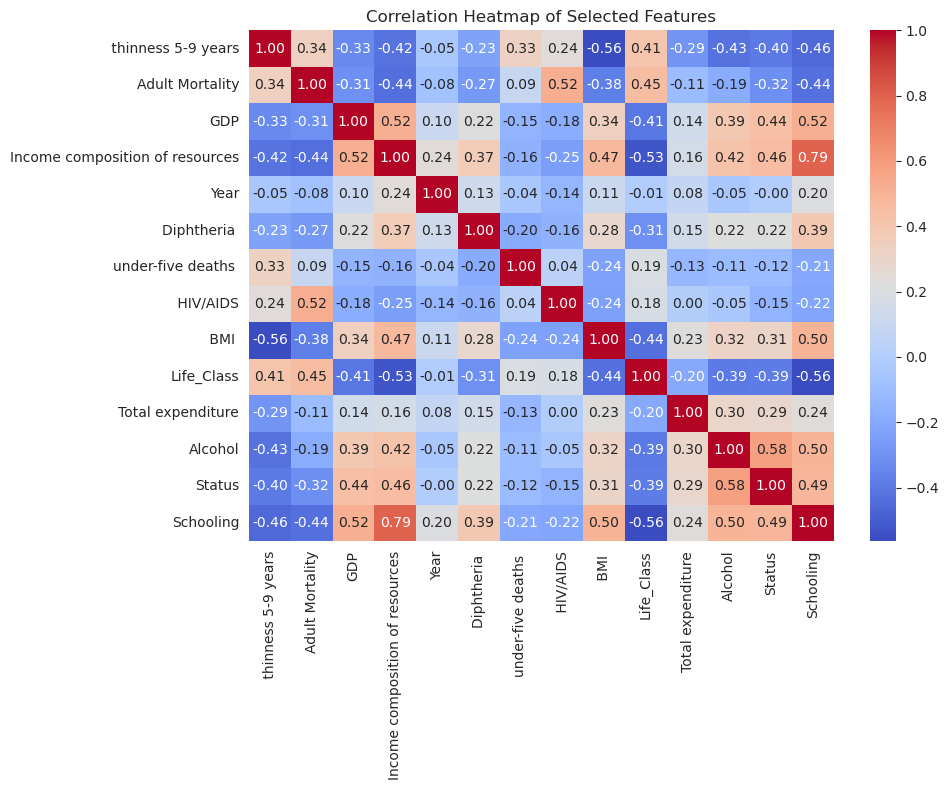

In [100]:
# 1. Correlation Heatmap of Final Features
plt.figure(figsize=(10, 8))
sns.heatmap(df[final_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()

plt.show()

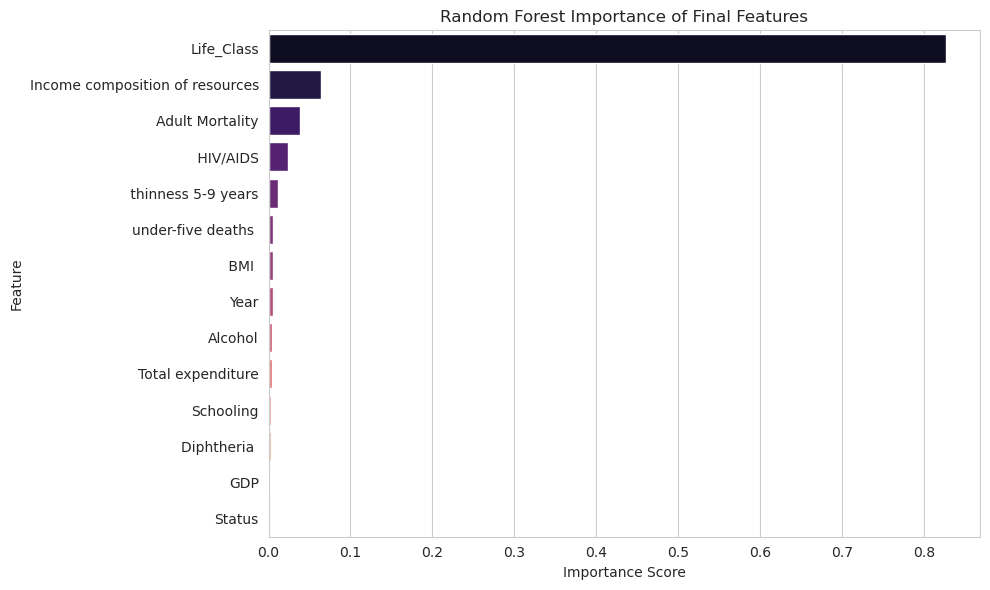

In [104]:
# 2. Random Forest Importance of Final Features
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(df[final_features], y)

rf_final_importances = pd.Series(rf_final.feature_importances_, index=final_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_final_importances.values, y=rf_final_importances.index, palette="magma")
plt.title("Random Forest Importance of Final Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [106]:
# Final dataset with selected features + target
final_df = df[final_features + ['Life expectancy ']]

# Quick check
print("Shape of final dataset:", final_df.shape)
print("Columns in final dataset:", final_df.columns.tolist())

Shape of final dataset: (2938, 15)
Columns in final dataset: [' thinness 5-9 years', 'Adult Mortality', 'GDP', 'Income composition of resources', 'Year', 'Diphtheria ', 'under-five deaths ', ' HIV/AIDS', ' BMI ', 'Life_Class', 'Total expenditure', 'Alcohol', 'Status', 'Schooling', 'Life expectancy ']


#model training 

In [108]:
X = final_df.drop(columns=['Life expectancy '])
y = final_df['Life expectancy ']

In [109]:
# 2. Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [110]:
# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [125]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [127]:
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [128]:
# 4. Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42)
}


In [130]:
# 5. Train & Evaluate

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results)
print("--- Model Performance Comparison ---")
print(results_df)

# Identify best model
best_model_name = results_df.sort_values(by='R2 Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")

--- Model Performance Comparison ---
               Model       MAE      RMSE  R2 Score
0  Linear Regression  2.728046  3.803237  0.833040
1      Random Forest  0.952119  1.495414  0.974188

Best Model: Random Forest


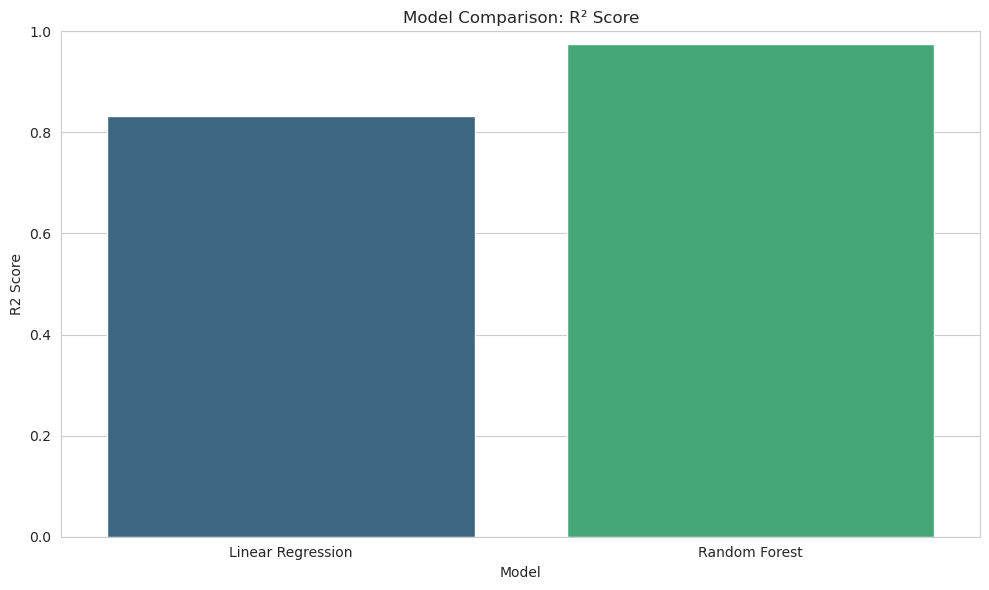

In [131]:
# 6. Visualization: Model Comparison

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('Model Comparison: R² Score')
plt.ylim(0, 1)
plt.tight_layout()

plt.show()

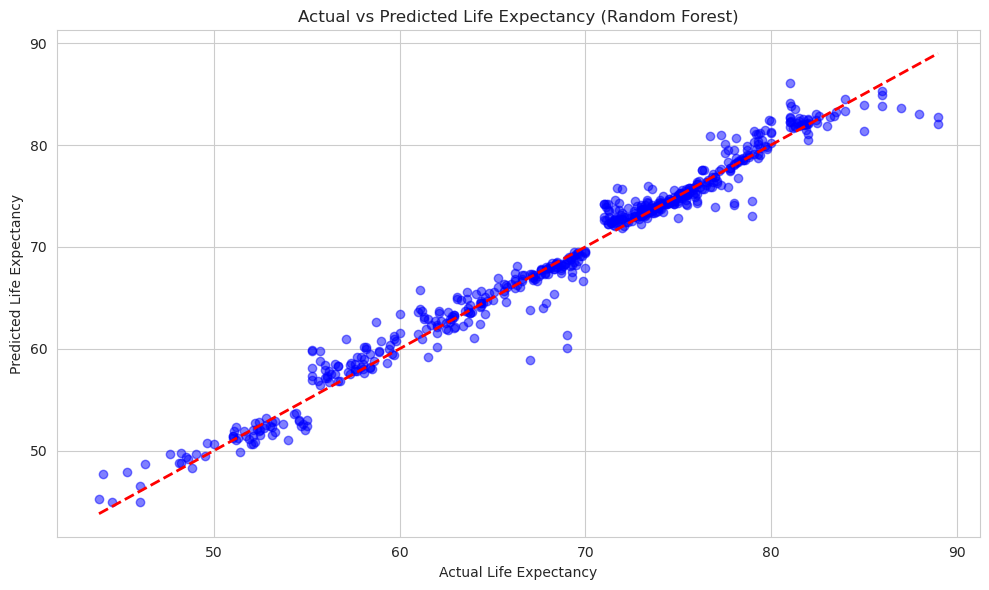

In [132]:
# 7. Visualization: Actual vs Predicted (Best Model)
# -------------------------------
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title(f'Actual vs Predicted Life Expectancy ({best_model_name})')
plt.tight_layout()

plt.show()

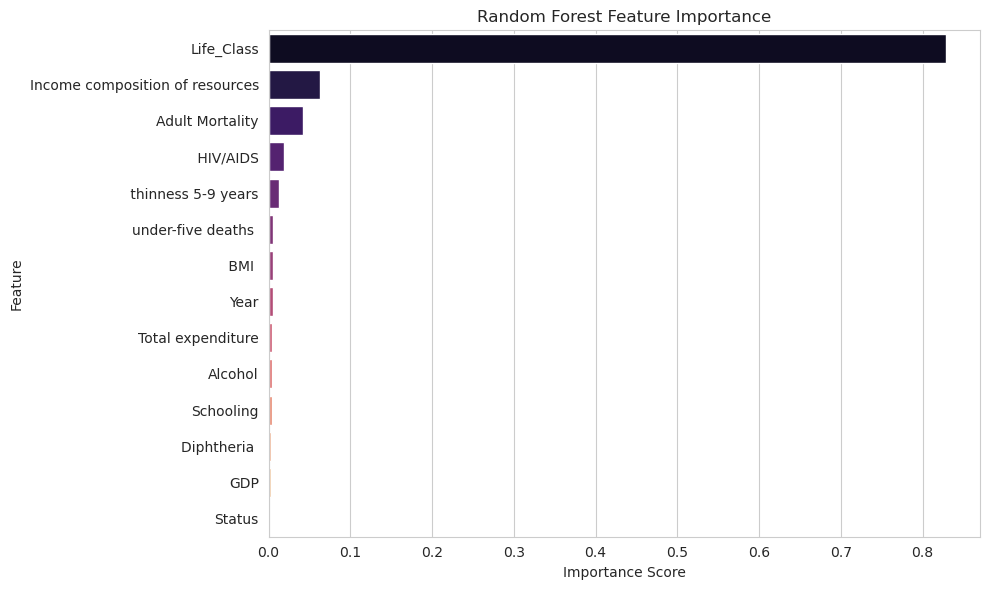

In [133]:
# 8. Feature Importance (if tree-based model)

if best_model_name == 'Random Forest':
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x=importances.values, y=importances.index, palette='magma')
    plt.title(f'{best_model_name} Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    
    plt.show()


What this version does:

Trains Linear Regression and Random Forest only.

Automatically selects the best model based on R².

Generates R² comparison bar chart and Actual vs Predicted scatter plot.

Plots feature importance if Random Forest is the best model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [ ]:

# Define model
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,              # number of combinations to try
    cv=5,                   # 5-fold CV
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)





In [ ]:
# Fit on training data
random_search.fit(X_train, y_train)

In [ ]:

# Best model
best_rf = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

In [ ]:
# Evaluate
y_pred = best_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
# Define features (X) and target (y)
X = df.drop(columns=['Life expectancy '])
y = df['Life expectancy ']

# Split the data (using same random state as before for consistency)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Define the Hyperparameter Grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# 2. Initialize GridSearchCV
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

# 3. Execute the Search
print("Starting Hyperparameter Tuning (Grid Search)...")
grid_search.fit(X_train_scaled, y_train)

# 4. Best Parameters and Best Score
print("\n--- Best Parameters Found ---")
print(grid_search.best_params_)
print(f"Best Cross-Validation R2 Score: {grid_search.best_score_:.4f}")

# 5. Evaluate the Optimized Model on Test Set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

# Metrics for Optimized Model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Optimized Model Performance (Test Set) ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")